/tmp/ipykernel_2920/714764082.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2920/714764082.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(df['Close'].iloc[i])



===== PERFORMANCE METRICS =====
Final Capital: 11303.58
Total Return: 13.04%
Annual Return: 3.16%
Sharpe Ratio: 0.43
Sortino Ratio: 0.06
Max Drawdown: 10.70%
Profit Factor: 1.97


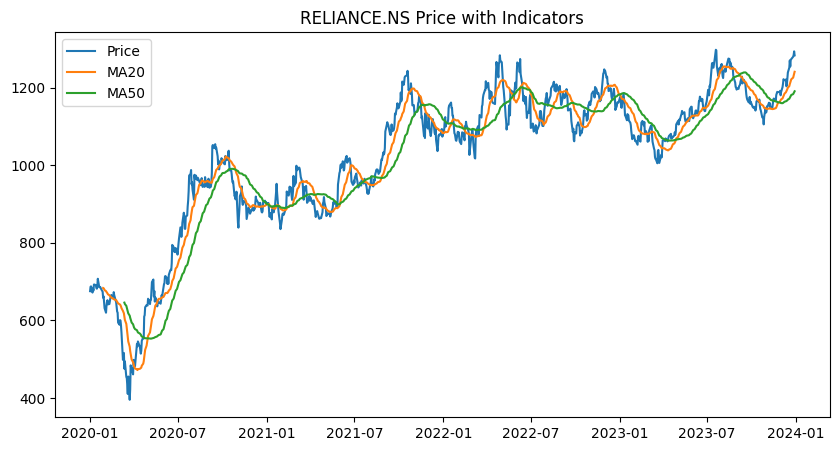

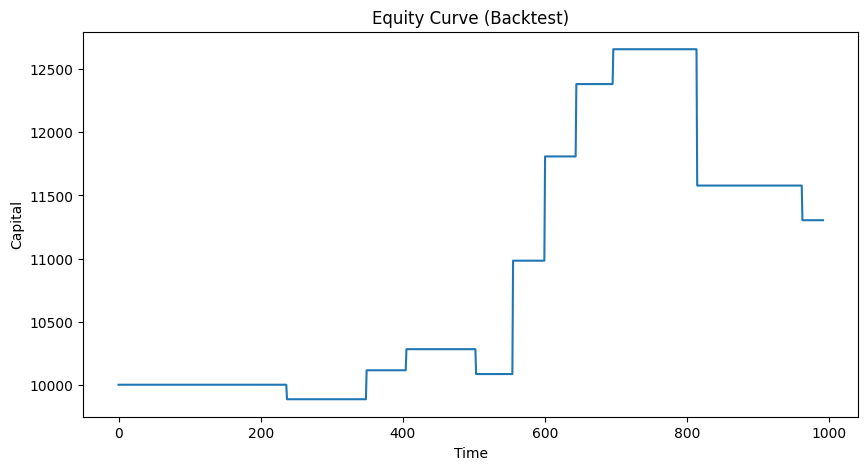

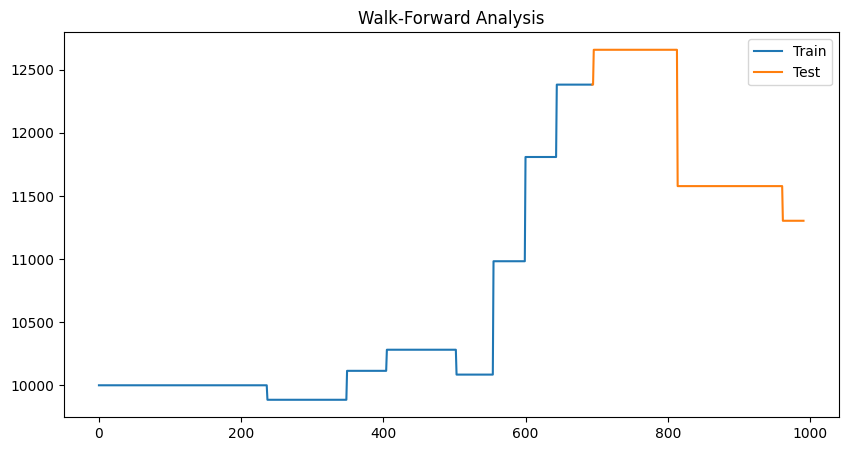

In [ ]:
#Evaluating & Enhancing the performance of trading algorithms

# 1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# 2. FETCH REAL MARKET DATA
# Choose asset:
# NSE Example: "RELIANCE.NS", "TCS.NS"
# Crypto Example: "BTC-USD", "ETH-USD"

ticker = "RELIANCE.NS"

df = yf.download(ticker, start="2020-01-01", end="2024-01-01")

df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.dropna(inplace=True)

# 3. TECHNICAL INDICATORS
# Moving Averages
df['MA20'] = df['Close'].rolling(20).mean()
df['MA50'] = df['Close'].rolling(50).mean()

# RSI
delta = df['Close'].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# 4. STRATEGY RULES
df['Signal'] = 0
df['Exit'] = 0

# Entry Condition (Trend + Oversold)
df['Signal'] = ((df['MA20'] > df['MA50']) & (df['RSI'] < 30)).astype(int)

# Exit Condition (Overbought)
df['Exit'] = (df['RSI'] > 70).astype(int)

# 5. BACKTEST ENGINE
initial_capital = 10000
capital = initial_capital
position = 0
entry_price = 0

equity_curve = []

for i in range(len(df)):

    price = float(df['Close'].iloc[i])
    signal = int(df['Signal'].iloc[i])
    exit_signal = int(df['Exit'].iloc[i])

    # BUY
    if signal == 1 and position == 0:
        position = capital / price
        entry_price = price

    # SELL
    elif position > 0 and exit_signal == 1:
        capital += (price - entry_price) * position
        position = 0

    equity_curve.append(capital)

# 6. PERFORMANCE METRICS
equity = pd.Series(equity_curve)

returns = equity.pct_change().dropna()

total_return = (equity.iloc[-1] / equity.iloc[0]) - 1
annual_return = (1 + total_return) ** (252 / len(equity)) - 1

sharpe = np.sqrt(252) * returns.mean() / returns.std()

sortino = np.sqrt(252) * returns.mean() / returns[returns < 0].std()

max_drawdown = ((equity.cummax() - equity) / equity.cummax()).max()

profit_factor = returns[returns > 0].sum() / abs(returns[returns < 0].sum())

print("\n===== PERFORMANCE METRICS =====")
print(f"Final Capital: {capital:.2f}")
print(f"Total Return: {total_return*100:.2f}%")
print(f"Annual Return: {annual_return*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Sortino Ratio: {sortino:.2f}")
print(f"Max Drawdown: {max_drawdown*100:.2f}%")
print(f"Profit Factor: {profit_factor:.2f}")

# 7. WALK-FORWARD (TRAIN / TEST SPLIT)
split = int(len(df) * 0.7)

train_equity = equity[:split]
test_equity = equity[split:]

# 8. VISUALIZATION
# Price + Indicators
plt.figure(figsize=(10,5))
plt.plot(df['Close'], label='Price')
plt.plot(df['MA20'], label='MA20')
plt.plot(df['MA50'], label='MA50')
plt.title(f"{ticker} Price with Indicators")
plt.legend()
plt.show()

# Equity Curve
plt.figure(figsize=(10,5))
plt.plot(equity_curve)
plt.title("Equity Curve (Backtest)")
plt.xlabel("Time")
plt.ylabel("Capital")
plt.show()

# Walk Forward Plot
plt.figure(figsize=(10,5))
plt.plot(train_equity, label="Train")
plt.plot(range(len(train_equity), len(equity)), test_equity, label="Test")
plt.title("Walk-Forward Analysis")
plt.legend()
plt.show()